<a href="https://colab.research.google.com/github/abidhasan5135-maker/Machine_Learning.369/blob/Machine_Branch/Decisiontree_KNN_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malicious URL Detection Using Machine Learning
**Instructor:** Md. Samiul Islam | **Lab:** Skill Morph Research Lab

**Dataset:** [Malicious URL Detection Dataset (Enhanced 2026)](https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026)

**Models:** Decision Tree · KNN · Logistic Regression | **Classes:** Benign · Defacement · Phishing · Malware

## 📑 Table of Contents

1. [Imports & Setup](#1-imports--setup)
2. [Data Loading](#2-data-loading)
3. [Data Inspection](#3-data-inspection)
4. [Preprocessing & Train-Test Split](#4-preprocessing--train-test-split)
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
6. [Model Training & Baseline Results](#6-model-training--baseline-results)
7. [Decision Tree — Depth Tuning](#7-decision-tree--depth-tuning)
8. [Classification Reports](#8-classification-reports)
9. [Confusion Matrices](#9-confusion-matrices)
10. [Model Comparison](#10-model-comparison)
11. [Assignment](#11-assignment)


## 1. Imports & Setup


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2. Data Loading


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SKILL_MOR_7/dataset_with_all_features v2.csv')
print(f"Shape: {df.shape}")
df.head()

Mounted at /content/drive
Shape: (651191, 68)


,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,...,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,...,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,...,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,...,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,...,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,...,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15


## 3. Data Inspection


In [ ]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])


Missing values per column:
 type         72
label        72
domain    12223
dtype: int64


In [ ]:
print("\nLabels:\n", df['label'].value_counts().sort_index())
print("\nClass mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware")


Labels:
 label
0.0    428209
1.0     96457
2.0     93933
3.0     32520
Name: count, dtype: int64

Class mapping: 0=Benign, 1=Defacement, 2=Phishing, 3=Malware


## 4. Preprocessing & Train-Test Split


In [ ]:
df.drop(columns=['url','domain','type','Date_inspection'], inplace=True)

# Handle missing values
df.fillna(df.median(numeric_only=True), inplace=True)

X = df.drop(columns=['label'])
y = df['label']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=20,stratify=y)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 520952 | Test: 130239


## 5. Exploratory Data Analysis (EDA)


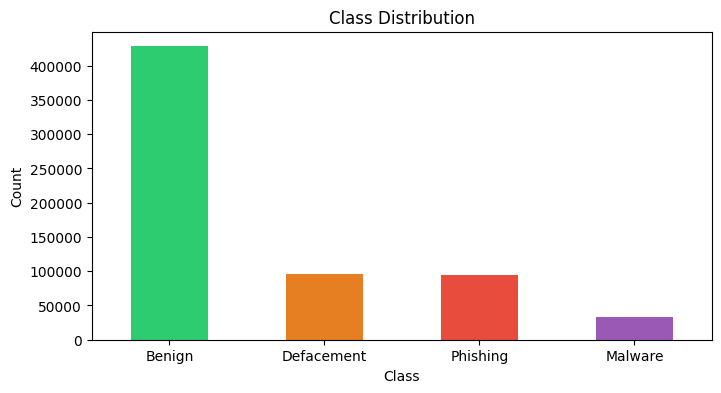

In [ ]:
labels = ['Benign', 'Defacement', 'Phishing', 'Malware']

counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))

counts.plot.bar(
    ax=ax,
    color=['#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']
)

ax.set_xticklabels(labels, rotation=0)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

plt.show()



## 6. Model Training & Baseline Results


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':     KNeighborsClassifier(n_neighbors=5),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=20)
}
results, predictions = {}, {}

for name, m in models.items():
    m.fit(X_train, y_train)
    yp = m.predict(X_test)
    predictions[name] = yp
    results[name] = {
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall':    recall_score(y_test, yp, average='weighted'),
        'F1-Score':  f1_score(y_test, yp, average='weighted')
    }
    print(f"{name}: Acc={results[name]['Accuracy']:.4f}  Precision = {results[name]['Precision']:.4f} Recall = {results[name]['Recall']:.4f} F1={results[name]['F1-Score']:.4f}")


Decision Tree: Acc=0.9577  Precision = 0.9575 Recall = 0.9577 F1=0.9576
KNN (k=5): Acc=0.9642  Precision = 0.9636 Recall = 0.9642 F1=0.9635
Logistic Reg: Acc=0.9023  Precision = 0.8992 Recall = 0.9023 F1=0.8949


## 7. Decision Tree — Depth Tuning


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8513     0.8230  0.8513    0.8192
5            0.8983     0.9002  0.8983    0.8898
10           0.9360     0.9364  0.9360    0.9329
15           0.9548     0.9545  0.9548    0.9533
20           0.9620     0.9615  0.9620    0.9609
None         0.9577     0.9575  0.9577    0.9576


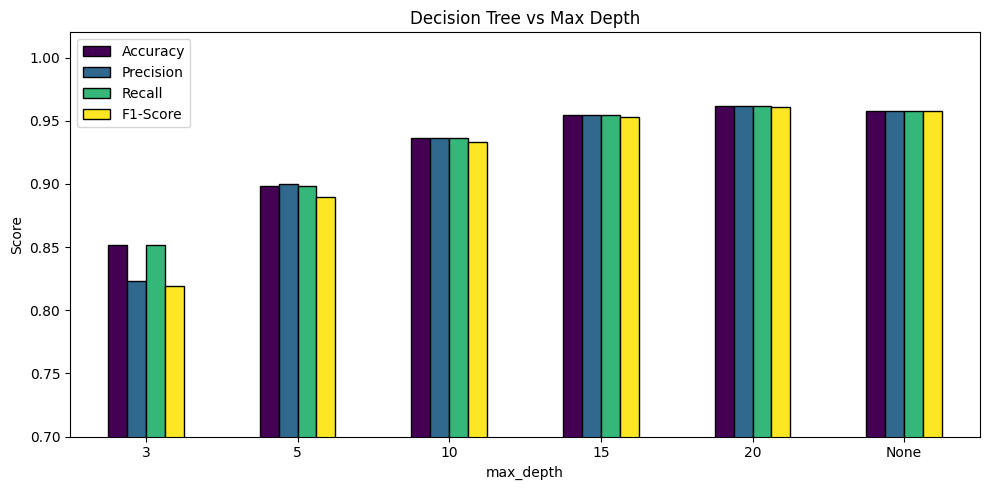

In [11]:
dt_results = []
for d in [3, 5, 10, 15, 20, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=20).fit(X_train, y_train)
    yp = dt.predict(X_test)
    dt_results.append({'max_depth': str(d) or 'None',
        'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp, average='weighted'),
        'Recall': recall_score(y_test, yp, average='weighted'), 'F1-Score': f1_score(y_test, yp, average='weighted')})

dt_df = pd.DataFrame(dt_results).set_index('max_depth')
print(dt_df.round(4))
dt_df.plot(kind='bar', figsize=(10,5), colormap='viridis', edgecolor='black')
plt.title('Decision Tree vs Max Depth'); plt.ylabel('Score'); plt.ylim(0.7, 1.02); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 8. Classification Reports


In [12]:
target_names = ['Benign', 'Defacement', 'Phishing', 'Malware']
for name, yp in predictions.items():
    print(f"\n{'='*55}\n{name}\n{'='*55}")
    print(classification_report(y_test, yp, target_names=target_names, digits=4))


Decision Tree
              precision    recall  f1-score   support

      Benign     0.9742    0.9757    0.9749     85657
  Defacement     0.9778    0.9813    0.9796     19291
    Phishing     0.8642    0.8565    0.8603     18787
     Malware     0.9469    0.9430    0.9449      6504

    accuracy                         0.9577    130239
   macro avg     0.9408    0.9391    0.9399    130239
weighted avg     0.9575    0.9577    0.9576    130239


KNN (k=5)
              precision    recall  f1-score   support

      Benign     0.9705    0.9890    0.9797     85657
  Defacement     0.9667    0.9873    0.9769     19291
    Phishing     0.9269    0.8393    0.8809     18787
     Malware     0.9692    0.9290    0.9487      6504

    accuracy                         0.9642    130239
   macro avg     0.9583    0.9361    0.9465    130239
weighted avg     0.9636    0.9642    0.9635    130239


Logistic Reg
              precision    recall  f1-score   support

      Benign     0.9145    0.9802  

## 9. Confusion Matrices


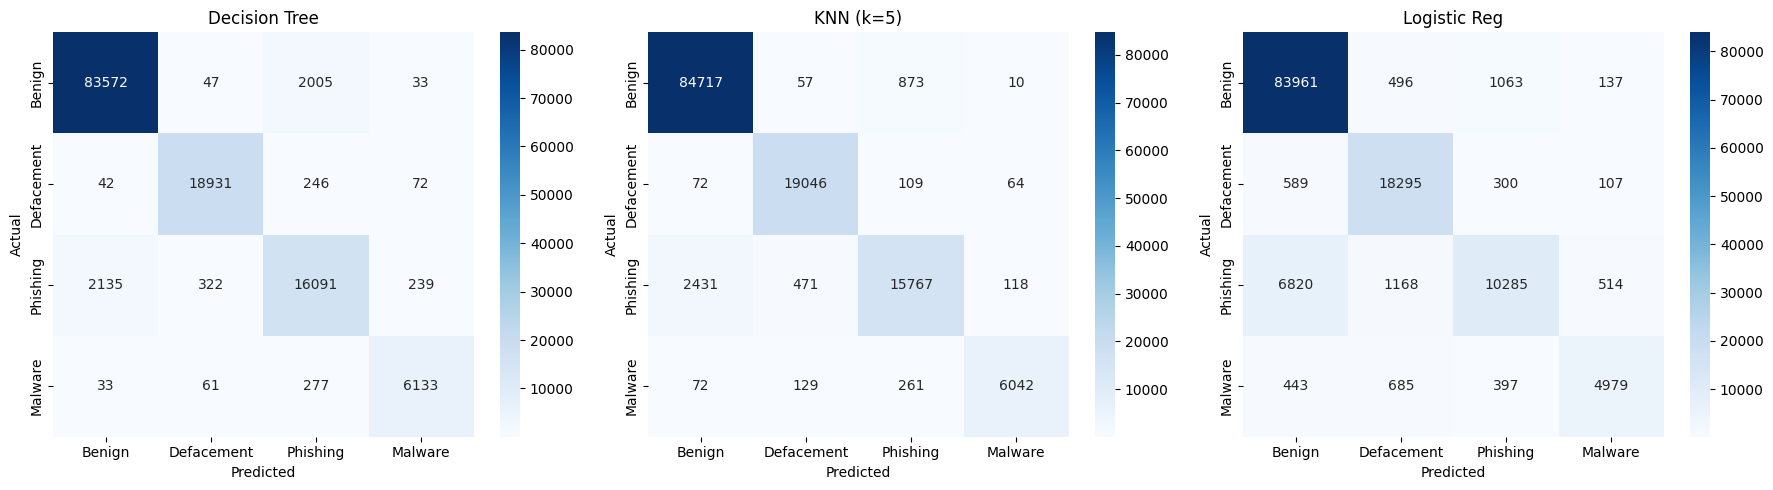

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp) in zip(axes, predictions.items()):
    sns.heatmap(confusion_matrix(y_test, yp), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

## 10. Model Comparison


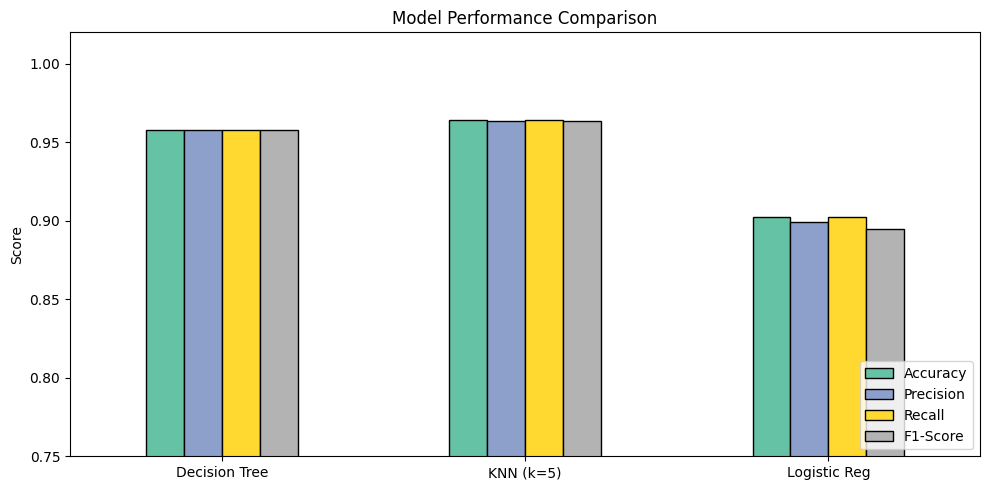


Summary:
                Accuracy  Precision  Recall  F1-Score
Decision Tree    0.9577     0.9575  0.9577    0.9576
KNN (k=5)        0.9642     0.9636  0.9642    0.9635
Logistic Reg     0.9023     0.8992  0.9023    0.8949


In [14]:
res_df = pd.DataFrame(results).T
res_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison'); plt.ylabel('Score'); plt.ylim(0.75, 1.02)
plt.xticks(rotation=0); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()
print("\nSummary:\n", res_df.round(4))

## 11. Assignment

**Dataset:** [Cybersecurity Intrusion Detection Dataset](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset)

Upload the dataset to your Google Drive under `datasets/` and complete the following tasks using the **same workflow** as this notebook.

| Task | What to do |
|------|------------|
| **1. Load & Inspect** | Load CSV, print shape, missing values, and class distribution |
| **2. Preprocess** | Drop irrelevant columns, fill missing values with median, scale features, split 80/20 |
| **3. EDA** | Bar chart of class distribution + top-10 feature correlations |
| **4. Train Models** | Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1 |
| **5. Depth Tuning** | Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart |
| **6. Evaluate** | Classification reports + 1×3 confusion matrix grid + model comparison bar chart |

**Submit:** Single `.ipynb` with all cells executed and clean output.

1. Load & Inspect	Load CSV, print shape, missing values, and class distribution

In [19]:
df = pd.read_csv('/content/drive/MyDrive/SKILL_MOR_7/cybersecurity_intrusion_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (9537, 11)


,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [32]:
print("\nMissing values per column:")
print(df.isnull().sum())

print("\nClass distribution (attack_detected):")
print(df['attack_detected'].value_counts())



Missing values per column:
session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

Class distribution (attack_detected):
attack_detected
0    5273
1    4264
Name: count, dtype: int64


2. Preprocess	Drop irrelevant columns, fill missing values with median, scale features, split 80/20

In [37]:
data = df.copy()

# 1) Drop irrelevant column: session_id is a unique label, not a predictive feature
data = data.drop(columns=['session_id'])

# 2) Fill missing values
#    - numeric columns -> median
#    - encryption_used is TEXT (AES/DES) so a median is impossible; a missing value
#      means "no encryption recorded", so we make that its own category
num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
data['encryption_used'] = data['encryption_used'].fillna('None')

# 3) Convert text columns to numbers (one-hot encoding)
cat_cols = ['protocol_type', 'encryption_used', 'browser_type']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)

# 4) Separate features (X) and target (y)
X = data.drop(columns=['attack_detected'])
y = data['attack_detected']

# 5) Split 80/20 (stratify keeps the class ratio equal in both sets)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=20, stratify=y)

# 6) Scale features (fit on TRAIN only, then apply to TEST)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Features used:", list(X.columns))
print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Missing values left:", data.isnull().sum().sum())

Features used: ['network_packet_size', 'login_attempts', 'session_duration', 'ip_reputation_score', 'failed_logins', 'unusual_time_access', 'protocol_type_TCP', 'protocol_type_UDP', 'encryption_used_DES', 'encryption_used_None', 'browser_type_Edge', 'browser_type_Firefox', 'browser_type_Safari', 'browser_type_Unknown']
Train: (7629, 14)  Test: (1908, 14)
Missing values left: 0




3. EDA	Bar chart of class distribution + top-10 feature correlations



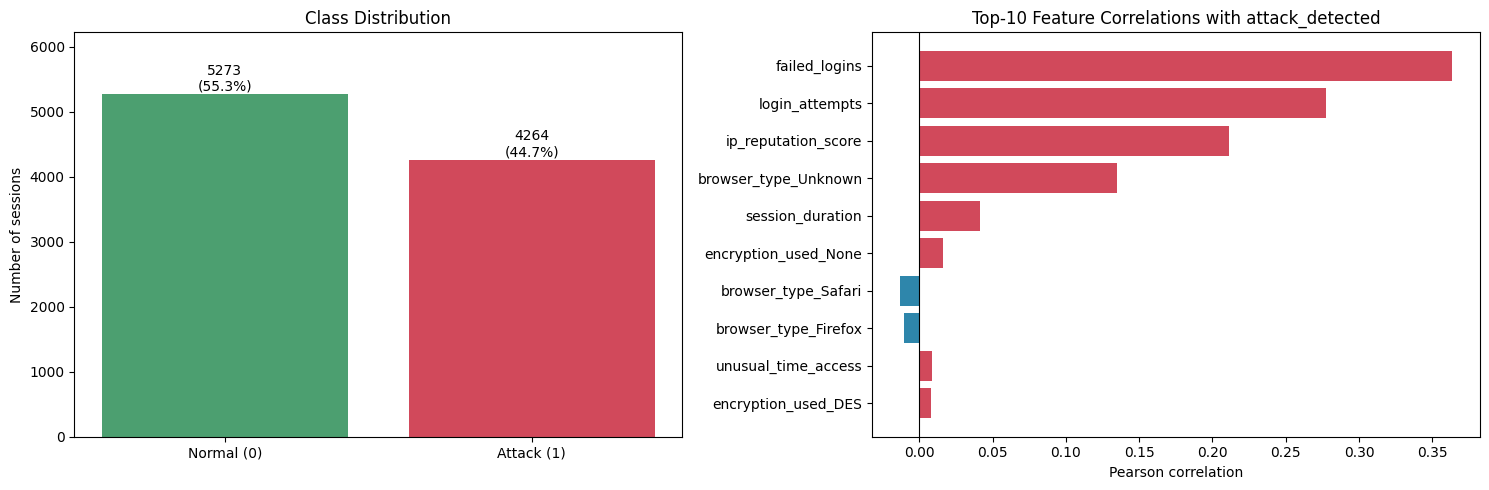

failed_logins           0.364
login_attempts          0.277
ip_reputation_score     0.212
browser_type_Unknown    0.135
session_duration        0.042
encryption_used_None    0.016
browser_type_Safari    -0.013
browser_type_Firefox   -0.011
unusual_time_access     0.009
encryption_used_DES     0.008
Name: attack_detected, dtype: float64


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Class distribution bar chart
counts = y.value_counts().sort_index()
axes[0].bar(['Normal (0)', 'Attack (1)'], counts.values, color=['#4C9F70', '#D1495B'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(y)*100:.1f}%)", ha='center')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of sessions')
axes[0].set_ylim(0, counts.max() * 1.18)

# (b) Top-10 features most correlated with the target
corr = data.corr()['attack_detected'].drop('attack_detected')
top10 = corr.reindex(corr.abs().sort_values(ascending=False).index)[:10]
colors = ['#D1495B' if v > 0 else '#2E86AB' for v in top10.values]
axes[1].barh(top10.index[::-1], top10.values[::-1], color=colors[::-1])
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Top-10 Feature Correlations with attack_detected')
axes[1].set_xlabel('Pearson correlation')

plt.tight_layout()
plt.show()
print(top10.round(3))

4. Train Models	Decision Tree, KNN (k=5), Logistic Regression — report Accuracy, Precision, Recall, F1

In [44]:
models = {
    'Decision Tree':       DecisionTreeClassifier(random_state=20),
    'KNN (k=5)':           KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=20),
}

preds, rows = {}, []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    preds[name] = y_pred
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-score':  f1_score(y_test, y_pred),
    })

results = pd.DataFrame(rows).set_index('Model').round(4)
results

,Accuracy,Precision,Recall,F1-score
Model,,,,
Decision Tree,0.8171,0.7864,0.8113,0.7986
KNN (k=5),0.7788,0.8372,0.6272,0.7172
Logistic Regression,0.7510,0.7357,0.6917,0.7130


5. Depth Tuning	Decision Tree with max_depth = [3, 5, 10, 15, 20, None] — table + bar chart

,max_depth,Train Acc,Test Acc,Precision,Recall,F1-score
0,3,0.8711,0.8747,1.0000,0.7198,0.8371
1,5,0.8916,0.8947,1.0000,0.7644,0.8664
2,10,0.8978,0.8957,0.9895,0.7749,0.8692
3,15,0.9131,0.8810,0.9408,0.7831,0.8548
4,20,0.9275,0.8684,0.9079,0.7855,0.8422
5,None,1.0000,0.8124,0.7765,0.8148,0.7952


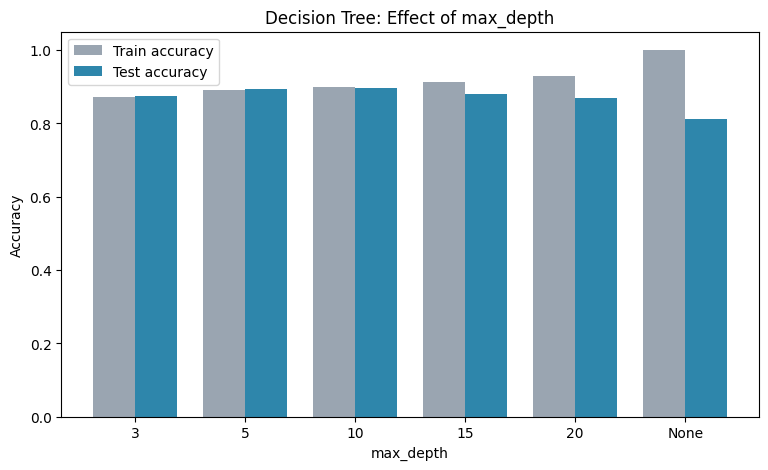

Best max_depth by test accuracy: 10 -> Test Acc = 0.8957


In [46]:
depths = [3, 5, 10, 15, 20, None]
tune_rows = []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=30)
    dt.fit(X_train_s, y_train)
    tune_rows.append({
        'max_depth':  'None' if d is None else d,
        'Train Acc':  accuracy_score(y_train, dt.predict(X_train_s)),
        'Test Acc':   accuracy_score(y_test,  dt.predict(X_test_s)),
        'Precision':  precision_score(y_test, dt.predict(X_test_s)),
        'Recall':     recall_score(y_test,    dt.predict(X_test_s)),
        'F1-score':   f1_score(y_test,        dt.predict(X_test_s)),
    })

tune_df = pd.DataFrame(tune_rows).round(4)
display(tune_df)

x = np.arange(len(tune_df)); w = 0.38
plt.figure(figsize=(9, 5))
plt.bar(x - w/2, tune_df['Train Acc'], w, label='Train accuracy', color='#9AA5B1')
plt.bar(x + w/2, tune_df['Test Acc'],  w, label='Test accuracy',  color='#2E86AB')
plt.xticks(x, tune_df['max_depth'].astype(str))
plt.xlabel('max_depth'); plt.ylabel('Accuracy'); plt.ylim(0, 1.05)
plt.title('Decision Tree: Effect of max_depth'); plt.legend()
plt.show()

best = tune_df.loc[tune_df['Test Acc'].idxmax()]
print("Best max_depth by test accuracy:", best['max_depth'], "-> Test Acc =", best['Test Acc'])

6. Evaluate	Classification reports + 1×3 confusion matrix grid + model comparison bar chart

In [47]:
# (a) Classification reports
for name, y_pred in preds.items():
    print("=" * 55); print(name); print("=" * 55)
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Decision Tree
              precision    recall  f1-score   support

      Normal       0.84      0.82      0.83      1055
      Attack       0.79      0.81      0.80       853

    accuracy                           0.82      1908
   macro avg       0.81      0.82      0.82      1908
weighted avg       0.82      0.82      0.82      1908

KNN (k=5)
              precision    recall  f1-score   support

      Normal       0.75      0.90      0.82      1055
      Attack       0.84      0.63      0.72       853

    accuracy                           0.78      1908
   macro avg       0.79      0.76      0.77      1908
weighted avg       0.79      0.78      0.77      1908

Logistic Regression
              precision    recall  f1-score   support

      Normal       0.76      0.80      0.78      1055
      Attack       0.74      0.69      0.71       853

    accuracy                           0.75      1908
   macro avg       0.75      0.75      0.75      1908
weighted avg       0.75      0